In [34]:
import json
import os
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import batch_utils

In [35]:
# Experiment definition
exp_group = 'batch_rxbkg_state1_mech1'
exp_name = 'net_newsec_ee_fade_var_seed'
#exp_group = 'batch_rxbkg_unconn_state1_mech1'
#exp_name = 'net_newsec_var_seed'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = dirpath_root / 'exp_results' / exp_group / exp_name

exp_names_sub = {
    #'surr': 'exp_ctx_unconn_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'full': 'exp_ctx_ee_1_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'ee_surr': 'exp_ctx_ee_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'ee_fade': 'exp_ctx_ee_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_unconn': 'exp_thal_unconn_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_ee_surr': 'exp_thal_ee_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'re_tc_surr': 'exp_thal_ire_tc_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_any_tc_surr': 'exp_thal_pe_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_ti_tc_surr': 'exp_thal_ti_tc_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_tc_ti_surr': 'exp_thal_tc_ti_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_tc_ti_fade': 'exp_thal_tc_ti_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_ti_tc_fade': 'exp_thal_ti_tc_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_full': 'exp_thal_ee_1_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'fade_all': 'exp_thal_all_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'core_full': 'exp_core_full_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'matx_full': 'exp_matx_full_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'tim_core_surr': 'exp_tim_core_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'matx_ti_surr': 'exp_matx_ti_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'matx_core_surr': 'exp_matx_core_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'irem_core_surr': 'exp_irem_core_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'irem_ti_surr': 'exp_irem_ti_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'irem_ire_surr': 'exp_irem_ire_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'irem_tc_surr': 'exp_irem_tc_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_surr': 'exp_a1_ee_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_irem_ire_surr': 'exp_a1_ee_0_irem_ire_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_fade_irem_ire_surr': 'exp_a1_ee_fade_irem_ire_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    #'a1_irem_ire_surr': 'exp_a1_irem_ire_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    #'a1_ee_irem_core_surr': 'exp_a1_ee_0_irem_core_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_surr_thal_ictrl': 'net_newsec_ctrl_var_seed/exp_a1_ee_0_nseed_15_t_10.0_15.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_ee_fade_thal_ictrl': 'net_newsec_ctrl_var_seed/exp_a1_ee_fade_nseed_15_t_10.0_15.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_ee_surr': 'net_newsec_ctrl_var_seed/exp_a1_ee_0_ictrl_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    #'a1_ee_fade': 'net_newsec_ctrl_var_seed/exp_a1_ee_fade_ictrl_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    #'a1_full_thal_ictrl': 'net_newsec_ctrl_var_seed/exp_a1_full_nseed_15_t_10.0_15.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_full': 'net_newsec_ctrl_var_seed/exp_a1_ee_full_ictrl_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    ###
    #'a1_ee_fade_1': 'net_newsec_ctrl_var_seed/exp_a1_ee_fade_nseed_15_t_10.0_15.0_ictrl_wmult_0.25_ee_0.5',
    'a1_ee_fade_0': 'net_newsec_var_seed/exp_a1_ee_fade_nseed_3_t_15.0_20.0_ictrl_wmult_0.25_ee_0.5',
    'a1_ee_fade': 'net_newsec_var_seed/exp_a1_ee_fade_nseed_15_t_15.0_20.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_ee_0': 'net_newsec_var_seed/exp_a1_ee_0_nseed_3_t_15.0_20.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_ee_1': 'net_newsec_var_seed/exp_a1_ee_1_nseed_3_t_15.0_20.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_ee_1_irem_ire_0': 'net_newsec_ee_fade_var_seed/exp_a1_irem_ire_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5'
    #'a1_ee_0_irem_ire_0': 'net_newsec_ee_fade_var_seed/exp_a1_ee_0_irem_ire_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_fade_irem_ire_0': 'exp_a1_ee_fade_irem_ire_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5'
}

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

pop_names = df.index.tolist()

In [36]:
R_all = {}

for exp_label, exp_name_sub in exp_names_sub.items():
    # Find json files with sim esults
    parts = exp_name_sub.split('/')
    dirpath_res_base = dirpath_res.parent if len(parts) == 2 else dirpath_res
    dirpath_data = dirpath_res_base / exp_name_sub / 'results'
    json_files = sorted(dirpath_data.glob('*.json'))
    n_trials = len(json_files)

    # Extract population rates from json files
    R = np.full((len(pop_names), n_trials), np.nan)
    for i, fpath in enumerate(json_files):
        with open(fpath, 'r') as fid:
            res = json.load(fid)
        for j, pop in enumerate(pop_names):
            R[j, i] = res['rates'].get(pop, np.nan)

    R = xr.DataArray(
        R,
        dims=['pop', 'trial'],
        coords={'pop': pop_names, 'trial': np.arange(n_trials)}
    )

    # Drop populations that have no valid rate in any trial
    R_all[exp_label] = R.sel(pop=~R.isnull().all(dim='trial'))


#### Plot rate distr. across seeds (multiple exp. setups, group by pop.)

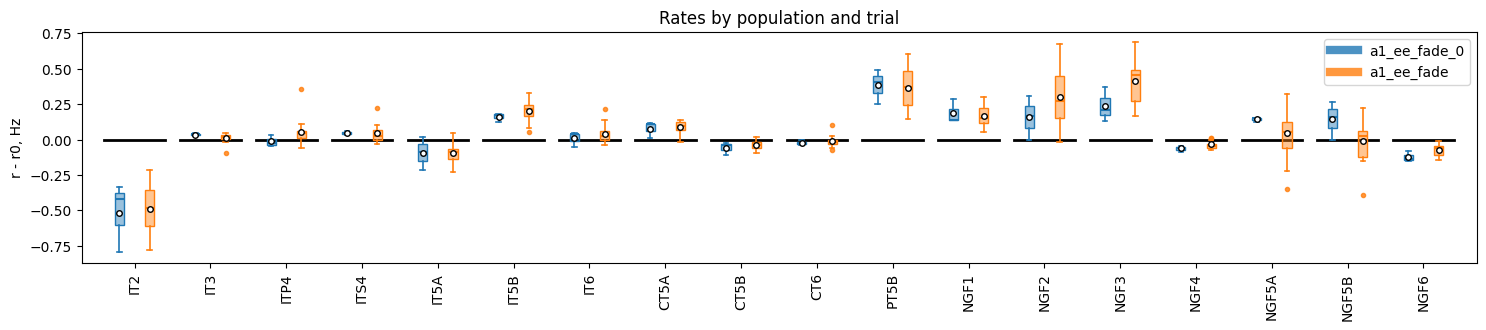

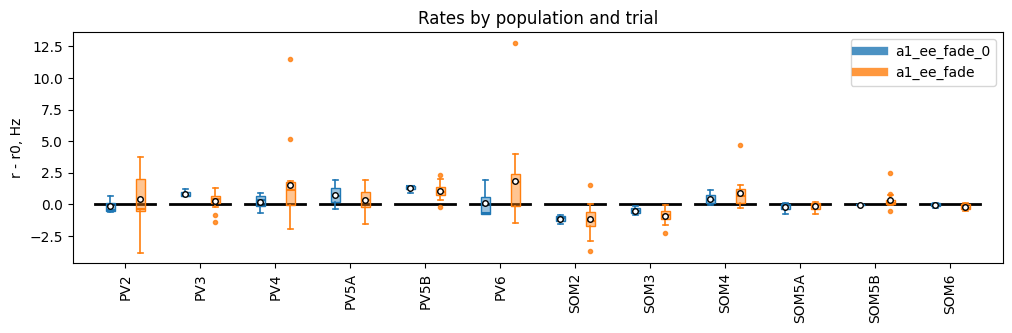

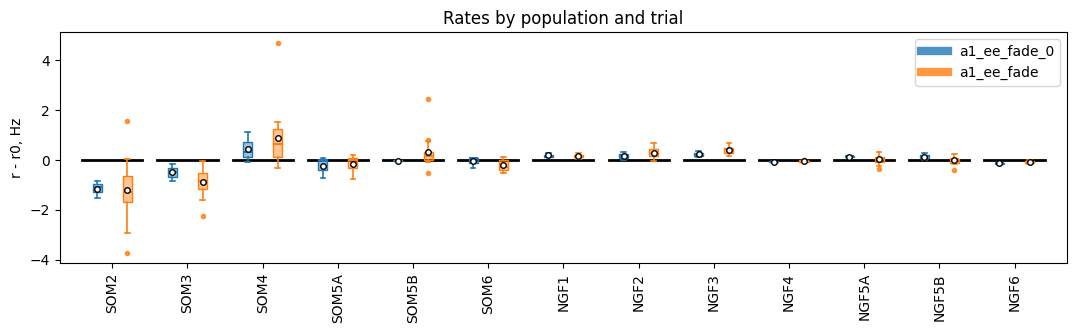

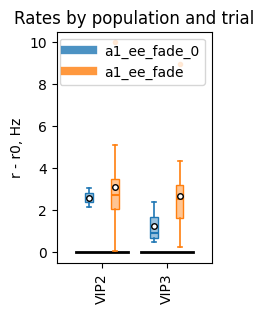

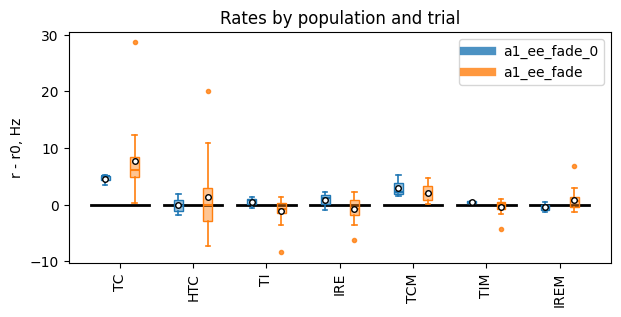

In [37]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'IT5B', 'IT6',
            'CT5A', 'CT5B', 'CT6', 'PT5B']
PV_POPS = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
VIP23_POPS = ['VIP2', 'VIP3']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

THAL_E_POPS = ['TC', 'HTC', 'TCM']
THAL_I_POPS = ['TI', 'TIM', 'IRE', 'IREM']
CORE_POPS = ['TC', 'HTC', 'TI', 'IRE']
MATX_POPS = ['TCM', 'TIM', 'IREM']
#THAL_POPS = THAL_E_POPS + THAL_I_POPS
THAL_POPS = CORE_POPS + MATX_POPS

groups_vis = [
    PYR_POPS + NGF_POPS,
    PV_POPS + SOM_POPS,
    SOM_POPS + NGF_POPS,
    VIP23_POPS,
    THAL_POPS
    #['IT2', 'IT3', 'ITP4', 'ITS4', 'IT6', 'CT5A', 'CT5B', 'CT6', 'PT5B'],
    #['IT5A', 'IT5B']    
]

def plot_rates(
        pops_vis,
        exp_labels=None,
        figsize=(10, 3),
        box_w=0.12, d=0.2,
        target_alpha=1, box_alpha=0.8, 
        normalize=False, center=False,
        legend=True, title=True, ylabel=True
        ):
    fig, ax = plt.subplots(figsize=figsize)

    if center and normalize:
        raise ValueError("Cannot center and normalize simultaneously.")

    exp_labels = exp_labels or list(R_all.keys())
    x_base = np.arange(len(pops_vis))
    colors = dict(zip(exp_labels, plt.cm.tab10.colors[:len(exp_labels)]))

    exp_labels = [l for l in exp_labels if l is not None]
    offsets = np.linspace(-d, d, len(exp_labels))

    # Target horizontal markers
    d1 = d * 2
    for ix, pop in enumerate(pops_vis):
        if center: target = 0
        elif normalize: target = 1
        else: target = df.loc[pop, 'target_rate']
        ax.plot([x_base[ix] - d1, x_base[ix] + d1], [target, target],
                color='black', linewidth=2, linestyle='-', zorder=0, alpha=target_alpha)

    # Grouped boxplots
    box_props = lambda c: dict(
        patch_artist=True, showmeans=True, meanline=False, whis=1.5, vert=True,
        boxprops=dict(facecolor=(*c, 0.45), edgecolor=c),
        medianprops=dict(color=c, linewidth=1.5),
        whiskerprops=dict(color=c, linewidth=1.2),
        capprops=dict(color=c, linewidth=1.2),
        meanprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=4),
        flierprops=dict(marker='.', markerfacecolor=c, markeredgecolor=c, alpha=box_alpha),
    )

    for offset, exp_label in zip(offsets, exp_labels):
        if exp_label is None:
            continue
        R_exp = R_all[exp_label].reindex(pop=pops_vis)
        data = [R_exp.sel(pop=pop).values for pop in pops_vis]
        data = [y[~np.isnan(y)] for y in data]
        positions = [x_base[ix] + offset for ix, y in enumerate(data) if len(y) > 0]
        data_valid = np.asarray([y for y in data if len(y) > 0])
        if center:
            data_valid = [y - df.loc[pop, 'target_rate']
                          for pop, y in zip(pops_vis, data) if len(y) > 0]
        elif normalize:
            data_valid = [y / df.loc[pop, 'target_rate']
                          for pop, y in zip(pops_vis, data) if len(y) > 0]
        else:
            data_valid = [y for y in data if len(y) > 0]
        
        try:
            ax.boxplot(data_valid, positions=positions, widths=box_w,
                    **box_props(colors[exp_label]))
        except:
            pass

    # Simple legend
    if legend:
        handles = [plt.Line2D([0], [0], color=colors[k], lw=6, alpha=box_alpha, label=k) for k in exp_labels]
        ax.legend(handles=handles)

    ax.set_xticks(x_base)
    ax.set_xticklabels(pops_vis, rotation=90)
    if ylabel:
        if center: ax.set_ylabel('r - r0, Hz')
        elif normalize: ax.set_ylabel('r / r0')
        else: ax.set_ylabel('Rate, Hz')
    if title:
        ax.set_title('Rates by population and trial')

for group in groups_vis:
    w = len(group)
    plot_rates(group, center=True, figsize=(w, 3), legend=1)

In [38]:
#exp_labels=['ee_surr', 'full']
#exp_labels=['unconn', 'full']
#exp_labels=['unconn', None, 'ee_surr']
#exp_labels=['unconn', None, 'ee_surr', 'fade']
#exp_labels=[None, 'full', None, 'fade']
exp_labels=[None, None, 'ee_surr', 'fade']

par = {'figsize': (10, 3), 'target_alpha': 0.5,
       'box_w': 0.2, 'box_alpha': 1, 'd': 0.15,
       'normalize': 0, 'center': 1, 'legend': 0,
       'title': 0, 'ylabel': 0}

#plot_rates(PYR_POPS + NGF_POPS + VIP_POPS, exp_labels, **par)
#plot_rates(PYR_POPS + NGF_POPS, exp_labels, **par)
#plot_rates(PV_POPS + SOM_POPS + NGF_POPS, exp_labels, **par)
#plot_rates(PYR_POPS + NGF_POPS + VIP_POPS, exp_labels, **par)
#plot_rates(VIP_POPS, exp_labels, **par)
#plot_rates(NGF_POPS, exp_labels, **par)

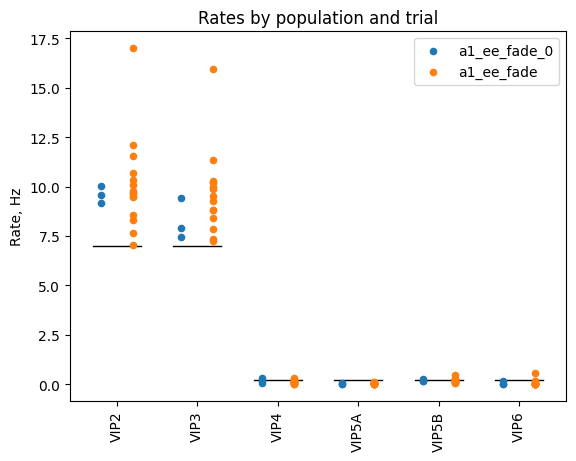

In [39]:
#pops_vis = ['IT2', 'IT3', 'PV2', 'PV3', 'SOM2', 'SOM3']
pops_vis = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']

d = 0.2
s = 20

#fig, ax = plt.subplots(figsize=(18, 6))
fig, ax = plt.subplots()

exp_labels = list(R_all.keys())
x_base = np.arange(len(pops_vis))
offsets = np.linspace(-d, d, len(exp_labels))
colors = dict(zip(exp_labels, plt.cm.tab10.colors[:len(exp_labels)]))

for ix, pop in enumerate(pops_vis):
    target = df.loc[pop, 'target_rate']
    d1 = d * 1.5
    ax.plot([x_base[ix] - d1, x_base[ix] + d1], [target, target],
            color='black', linewidth=1, linestyle='-', zorder=0)

for offset, exp_label in zip(offsets, exp_labels):
    R_exp = R_all[exp_label].reindex(pop=pops_vis)

    for ix, pop in enumerate(pops_vis):
        y = R_exp.sel(pop=pop).values
        y = y[~np.isnan(y)]
        if len(y) == 0:
            continue

        x = np.full(len(y), x_base[ix] + offset)
        ax.scatter(x, y, s=s, alpha=1, color=colors[exp_label],
                   label=exp_label if ix == 0 else None)

ax.set_xticks(x_base)
ax.set_xticklabels(pops_vis, rotation=90)
#ax.set_xlabel('pop')
ax.set_ylabel('Rate, Hz')
ax.set_title('Rates by population and trial')
ax.legend()   #title='exp_label')
#ax.grid(axis='y', alpha=0.3)
#plt.tight_layout()

#### Plot errors

In [40]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
from netpyne.analysis.utils import colorList
import numpy as np


def make_pop_colors_from_groups(color_groups, colors=None):
    """
    color_groups:
        either list of lists
        or dict: group_name -> list of populations

    Returns:
        dict: pop -> color
    """
    if colors is None:
        #colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        colors = colorList

    if isinstance(color_groups, dict):
        groups = list(color_groups.values())
    else:
        groups = color_groups

    pop_colors = {}
    for i, group in enumerate(groups):
        c = colors[i % len(colors)]
        for pop in group:
            pop_colors[pop] = c
    return pop_colors


def _set_nice_xticks(ax, xmin, xmax, nbins=4, include_zero=True,
                     require_pos_tick=True, require_neg_tick=True):
    """
    Put a small number of readable ticks, while ensuring:
      - 0 is present if requested
      - at least one positive tick exists when xmax > 0
      - at least one negative tick exists when xmin < 0
    """
    ax.xaxis.set_major_locator(MaxNLocator(nbins=nbins, min_n_ticks=3))

    ticks = ax.get_xticks()
    ticks = np.asarray(ticks)
    ticks = ticks[(ticks >= xmin - 1e-12) & (ticks <= xmax + 1e-12)]

    extra = []

    if include_zero and xmin < 0 < xmax:
        if not np.any(np.isclose(ticks, 0)):
            extra.append(0.0)

    if require_pos_tick and xmax > 0:
        if not np.any(ticks > 0):
            extra.append(xmax)

    if require_neg_tick and xmin < 0:
        if not np.any(ticks < 0):
            extra.append(xmin)

    if extra:
        ticks = np.unique(np.concatenate([ticks, np.array(extra)]))
        ticks.sort()

    ax.set_xticks(ticks)


def plot_rates(
    pops_vis,
    exp_label,
    fig_w=10,
    y_step=0.38,
    top_in=None,
    bottom_in=None,
    left_in=0.65,
    right_in=0.08,
    box_h=0.65,
    target_alpha=1,
    box_alpha=0.85,
    box_face_alpha=0.5,
    normalize=False,
    center=False,
    legend=False,
    title=True,
    xlabel=True,
    pop_colors=None,
    color_groups=None,
    show_target=True,
    zero_line=False,
    center_xlim=False,
    xlim_margin=0.1,
    invert_yaxis=True,
    sort_key=None,

    # new options
    ensure_zero_visible=True,
    zero_pad_frac=0.08,      # extra room so x=0 is inside the panel, not on the edge
    xtick_nbins=4,
    ensure_side_ticks=True,
    colored_mean=True,
):
    """
    Plot horizontal rate boxplots with fixed visual y spacing per population.

    Requires:
        R_all[exp_label] : xarray object with dimension 'pop'
        df.loc[pop, 'target_rate']
    """

    if color_groups is not None:
        pop_colors = make_pop_colors_from_groups(color_groups)

    pops_vis = list(pops_vis)
    if sort_key is not None:
        pops_vis = sorted(pops_vis, key=sort_key)

    R_exp = R_all[exp_label].reindex(pop=pops_vis)

    valid_pops = []
    for pop in pops_vis:
        x = R_exp.sel(pop=pop).values
        x = x[~np.isnan(x)]
        if len(x) > 0:
            valid_pops.append(pop)

    n_pop = max(len(valid_pops), 1)

    if top_in is None:
        top_in = 0.35 if title else 0.08
    if bottom_in is None:
        bottom_in = 0.45 if xlabel else 0.28

    ax_h = y_step * n_pop
    fig_h = ax_h + top_in + bottom_in

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    fig.subplots_adjust(
        left=left_in / fig_w,
        right=1 - right_in / fig_w,
        bottom=bottom_in / fig_h,
        top=1 - top_in / fig_h,
    )

    default_color = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]

    y_pos = []
    y_labels = []
    all_vals = []

    for pop in valid_pops:
        x = R_exp.sel(pop=pop).values
        x = x[~np.isnan(x)]

        if center:
            target = 0
            x = x - df.loc[pop, 'target_rate']
        elif normalize:
            target = 1
            x = x / df.loc[pop, 'target_rate']
        else:
            target = df.loc[pop, 'target_rate']

        pos = len(y_pos)
        c = pop_colors.get(pop, default_color) if pop_colors is not None else default_color

        face_c = mcolors.to_rgba(c, box_face_alpha)
        edge_c = mcolors.to_rgba(c, box_alpha)

        if colored_mean:
            meanprops = dict(
                marker='o',
                markerfacecolor=c,
                markeredgecolor='white',
                markersize=5,
            )
        else:
            meanprops = dict(
                marker='o',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=4,
            )

        ax.boxplot(
            [x],
            positions=[pos],
            vert=False,
            widths=box_h,
            patch_artist=True,
            showmeans=True,
            meanline=False,
            whis=1.5,
            boxprops=dict(facecolor=face_c, edgecolor=edge_c),
            medianprops=dict(color=edge_c, linewidth=1.5),
            whiskerprops=dict(color=edge_c, linewidth=1.2),
            capprops=dict(color=edge_c, linewidth=1.2),
            meanprops=meanprops,
            flierprops=dict(
                marker='.',
                markerfacecolor=edge_c,
                markeredgecolor=edge_c,
                alpha=box_alpha,
            ),
        )

        if show_target and not zero_line:
            ax.plot(
                [target, target],
                [pos - box_h * 0.55, pos + box_h * 0.55],
                color='black',
                linewidth=2,
                alpha=target_alpha,
                zorder=3,
            )

        y_pos.append(pos)
        y_labels.append(pop)
        all_vals.extend(x.tolist())

    if zero_line and len(y_pos) > 0:
        ax.axvline(
            0,
            color='black',
            linewidth=1,
            alpha=target_alpha * 0.7,
            zorder=0,
        )

    if len(y_pos) > 0:
        ax.set_ylim(-0.5, len(y_pos) - 0.5)
        if invert_yaxis:
            ax.invert_yaxis()

    # ---------- x limits ----------
    if len(all_vals) > 0:
        if center_xlim:
            vmax = max(abs(v) for v in all_vals)
            if vmax == 0:
                vmax = 1.0
            xmax = vmax * (1 + xlim_margin)
            xmin = -xmax
        else:
            xmin = min(all_vals)
            xmax = max(all_vals)
            span = xmax - xmin

            if span == 0:
                pad = abs(xmax) * 0.1 if xmax != 0 else 1.0
            else:
                pad = span * xlim_margin

            xmin = xmin - pad
            xmax = xmax + pad

        if ensure_zero_visible:
            ref = max(abs(xmin), abs(xmax), 1.0)
            zero_pad = zero_pad_frac * ref

            if xmin >= 0:
                xmin = -zero_pad
            if xmax <= 0:
                xmax = zero_pad

        ax.set_xlim(xmin, xmax)

        # ---------- ticks ----------
        _set_nice_xticks(
            ax,
            xmin,
            xmax,
            nbins=xtick_nbins,
            include_zero=zero_line or ensure_zero_visible,
            require_pos_tick=ensure_side_ticks,
            require_neg_tick=ensure_side_ticks,
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)

    if xlabel:
        if center:
            ax.set_xlabel('r - r0, Hz')
        elif normalize:
            ax.set_xlabel('r / r0')
        else:
            ax.set_xlabel('Rate, Hz')

    if title:
        ax.set_title(f'Rates by population and trial ({exp_label})')

    if legend:
        handle = plt.Line2D(
            [0], [0],
            color=default_color,
            lw=6,
            alpha=box_alpha,
            label=exp_label,
        )
        ax.legend(handles=[handle])

    ax.grid(axis='x', alpha=0.25)

    return fig, ax

In [41]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'CT5A',
            'IT5B', 'CT5B', 'PT5B', 'IT6', 'CT6']
PV_POPS = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
VIP23_POPS = ['VIP2', 'VIP3']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

L1_POPS = ['NGF1']
L2_POPS = ['IT2', 'PV2', 'SOM2', 'VIP2', 'NGF2']
L3_POPS = ['IT3', 'PV3', 'SOM3', 'VIP3', 'NGF3']
L4_POPS = ['ITP4', 'ITS4', 'PV4', 'SOM4', 'VIP4', 'NGF4']
L5A_POPS = ['IT5A', 'CT5A', 'PV5A', 'SOM5A', 'VIP5A', 'NGF5A']
L5B_POPS = ['IT5B', 'CT5B', 'PT5B', 'PV5B', 'SOM5B', 'VIP5B', 'NGF5B']
L6_POPS = ['IT6', 'CT6', 'PV6', 'SOM6', 'VIP6', 'NGF6']

THAL_RE_POPS = ['IRE', 'IREM']
THAL_CORE_POPS = ['TC', 'HTC', 'TI']
THAL_MATRIX_POPS = ['TCM', 'TIM'] 

THAL_E_POPS = ['TC', 'HTC', 'TCM']
THAL_I_POPS = ['TI', 'TIM', 'IRE', 'IREM']
CORE_POPS = ['TC', 'HTC', 'TI', 'IRE']
MATX_POPS = ['TCM', 'TIM', 'IREM']
#THAL_POPS = THAL_E_POPS + THAL_I_POPS
THAL_POPS = CORE_POPS + MATX_POPS

In [42]:
plt.rcParams['axes.prop_cycle'].by_key()['color']

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

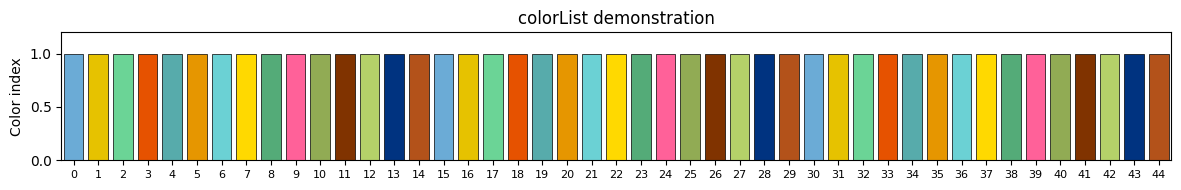

In [43]:
from netpyne.analysis.utils import colorList

# Demonstrate colorList with vertical bars
fig, ax = plt.subplots(figsize=(12, 2))
for i, color in enumerate(colorList):
    ax.bar(i, 1, color=color, width=0.8, edgecolor='black', linewidth=0.5)
ax.set_xlim(-0.5, len(colorList) - 0.5)
ax.set_ylim(0, 1.2)
ax.set_xticks(range(len(colorList)))
ax.set_xticklabels(range(len(colorList)), fontsize=8)
ax.set_ylabel('Color index')
ax.set_title('colorList demonstration')
plt.tight_layout()
plt.show()

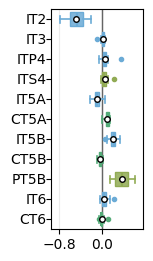

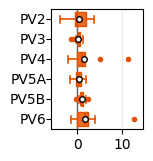

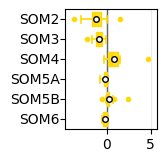

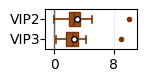

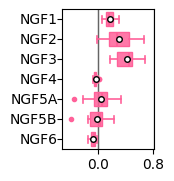

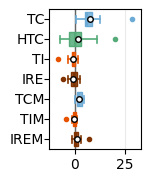

In [44]:
color_groups_by_layer = [
    ['IT2', 'PV2', 'SOM2', 'VIP2', 'NGF2', 'TC', 'HTC', 'TCM'],
    ['IT3', 'PV3', 'SOM3', 'VIP3', 'NGF3', 'TI', 'TIM'],
    ['ITP4', 'ITS4', 'PV4', 'SOM4', 'VIP4', 'NGF4', 'IRE', 'IREM'],
    ['IT5A', 'CT5A', 'PV5A', 'SOM5A', 'VIP5A', 'NGF5A'],
    ['IT5B', 'CT5B', 'PT5B', 'PV5B', 'SOM5B', 'VIP5B', 'NGF5B'],
    ['IT6', 'CT6', 'PV6', 'SOM6', 'VIP6', 'NGF6'],
    ['NGF1']
]
color_groups_by_type_0 = [
    ['IT2', 'IT3', 'ITP4', 'IT5A', 'IT5B', 'IT6', 'TC', 'TCM'],
    ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6'],
    #['CT5A', 'CT5B', 'CT6', 'HTC'],
    [],
    ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6', 'TI', 'TIM'],
    ['ITS4', 'PT5B'],
    [],
    ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6'],
    ['CT5A', 'CT5B', 'CT6', 'HTC'],
    ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6', 'IRE', 'IREM'],
    #['IRE', 'IREM'],
    #['TC', 'HTC', 'TCM'],
    #['TI', 'TIM']
]
color_groups_by_type = [
    ['IT2', 'IT3', 'ITP4', 'IT5A', 'IT5B', 'IT6', 'TC', 'TCM'],
    #['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6'],
    [],
    #['ITS4', 'PT5B'],
    [],
    ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6', 'TI', 'TIM'],
    [],
    [],
    [],
    ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6'],
    ['CT5A', 'CT5B', 'CT6', 'HTC'],
    ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6'],
    ['ITS4', 'PT5B'],
    ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6', 'IRE', 'IREM'],
]
color_groups = color_groups_by_type

groups_vis = [
    PYR_POPS,
    PV_POPS,
    SOM_POPS,
    VIP23_POPS,
    NGF_POPS,
    THAL_POPS,
]

for group in groups_vis:
    fig, ax = plot_rates(
        group,
        exp_label='a1_ee_fade',
        center=True,
        fig_w=1.6,
        y_step=0.2,
        box_h=0.7,
        title=False,
        xlabel=False,
        left_in=0.6,
        right_in=0.08,
        top_in=0.08,
        bottom_in=0.28,
        color_groups=color_groups,
        zero_line=True,
        center_xlim=False,
        xlim_margin=0.12,
        ensure_zero_visible=1,
        ensure_side_ticks=0,
        #xtick_nbins=4,
        colored_mean=0,
        box_alpha=1,
        box_face_alpha=0.85
    )

    ax.xaxis.set_major_locator(MaxNLocator(nbins=2))
    ax.tick_params(axis='x', labelsize=10, pad=2)
    ax.tick_params(axis='y', labelsize=10, pad=0)
    plt.setp(ax.get_yticklabels(), va='center')

    plt.show()

#### Plot rate dynamics

In [45]:
import pickle
from analysis.ou_tuning import sim_res_proc_utils as proc

#fpath_data = Path('/ddn/niknovikov19/repo/A1_OUinp/exp_results/batch_rxbkg_state1_mech1/net_newsec_ee_fade_var_seed'
                  #'/exp_ctx_unconn_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5/pkl/data_00001_seed_1001.pkl')
#                  '/exp_ctx_ee_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5/pkl/data_00000_seed_1000.pkl')
fpath_data = (dirpath_root / 'exp_results' / 'batch_rxbkg_state1_mech1' / 
              'net_newsec_var_seed' / 'exp_a1_ee_fade_nseed_3_t_15.0_20.0_ictrl_wmult_0.25_ee_0.5' /
              'pkl' / 'data_00000_seed_1000.pkl')

with open(fpath_data, 'rb') as fid:
    sim_res = pickle.load(fid)

([], [])

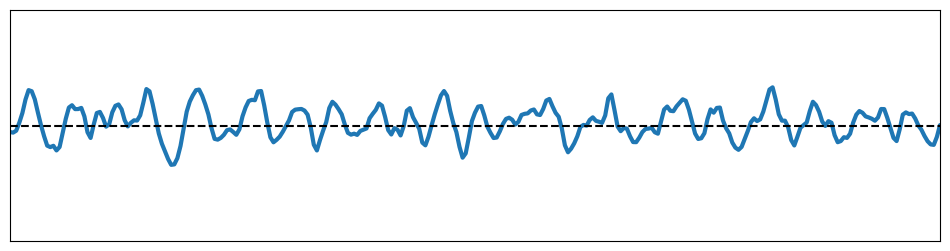

In [46]:
pop = 'IT3'

# Compute rate dynamics
r_data = proc.calc_rate_dynamics(
    sim_res, t_limits=(0, None), tau_smooth=0.005, pops_used=[pop])

plt.figure(figsize=(12, 3))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

tt, rr = r_data[pop]
r0 = sim_res['simConfig']['target_rates'][pop]
col = colors[0]
plt.plot(tt, rr, label=pop, color=col, linewidth=3)
plt.plot([tt[0], tt[-1]], [r0, r0], 'k--')

#plt.xlabel('Time')
#plt.ylabel('Firing rate')
#plt.legend(bbox_to_anchor=(1, 1))
plt.ylim([0, 4])
#plt.ylim([0, 40])
plt.xlim(6, 7.5)
#plt.xlim(13, 14.5)
plt.xticks([])
plt.yticks([])


Start time:  2026-07-16 02:41:29.900399
Preparing spike data...
Plotting raster...


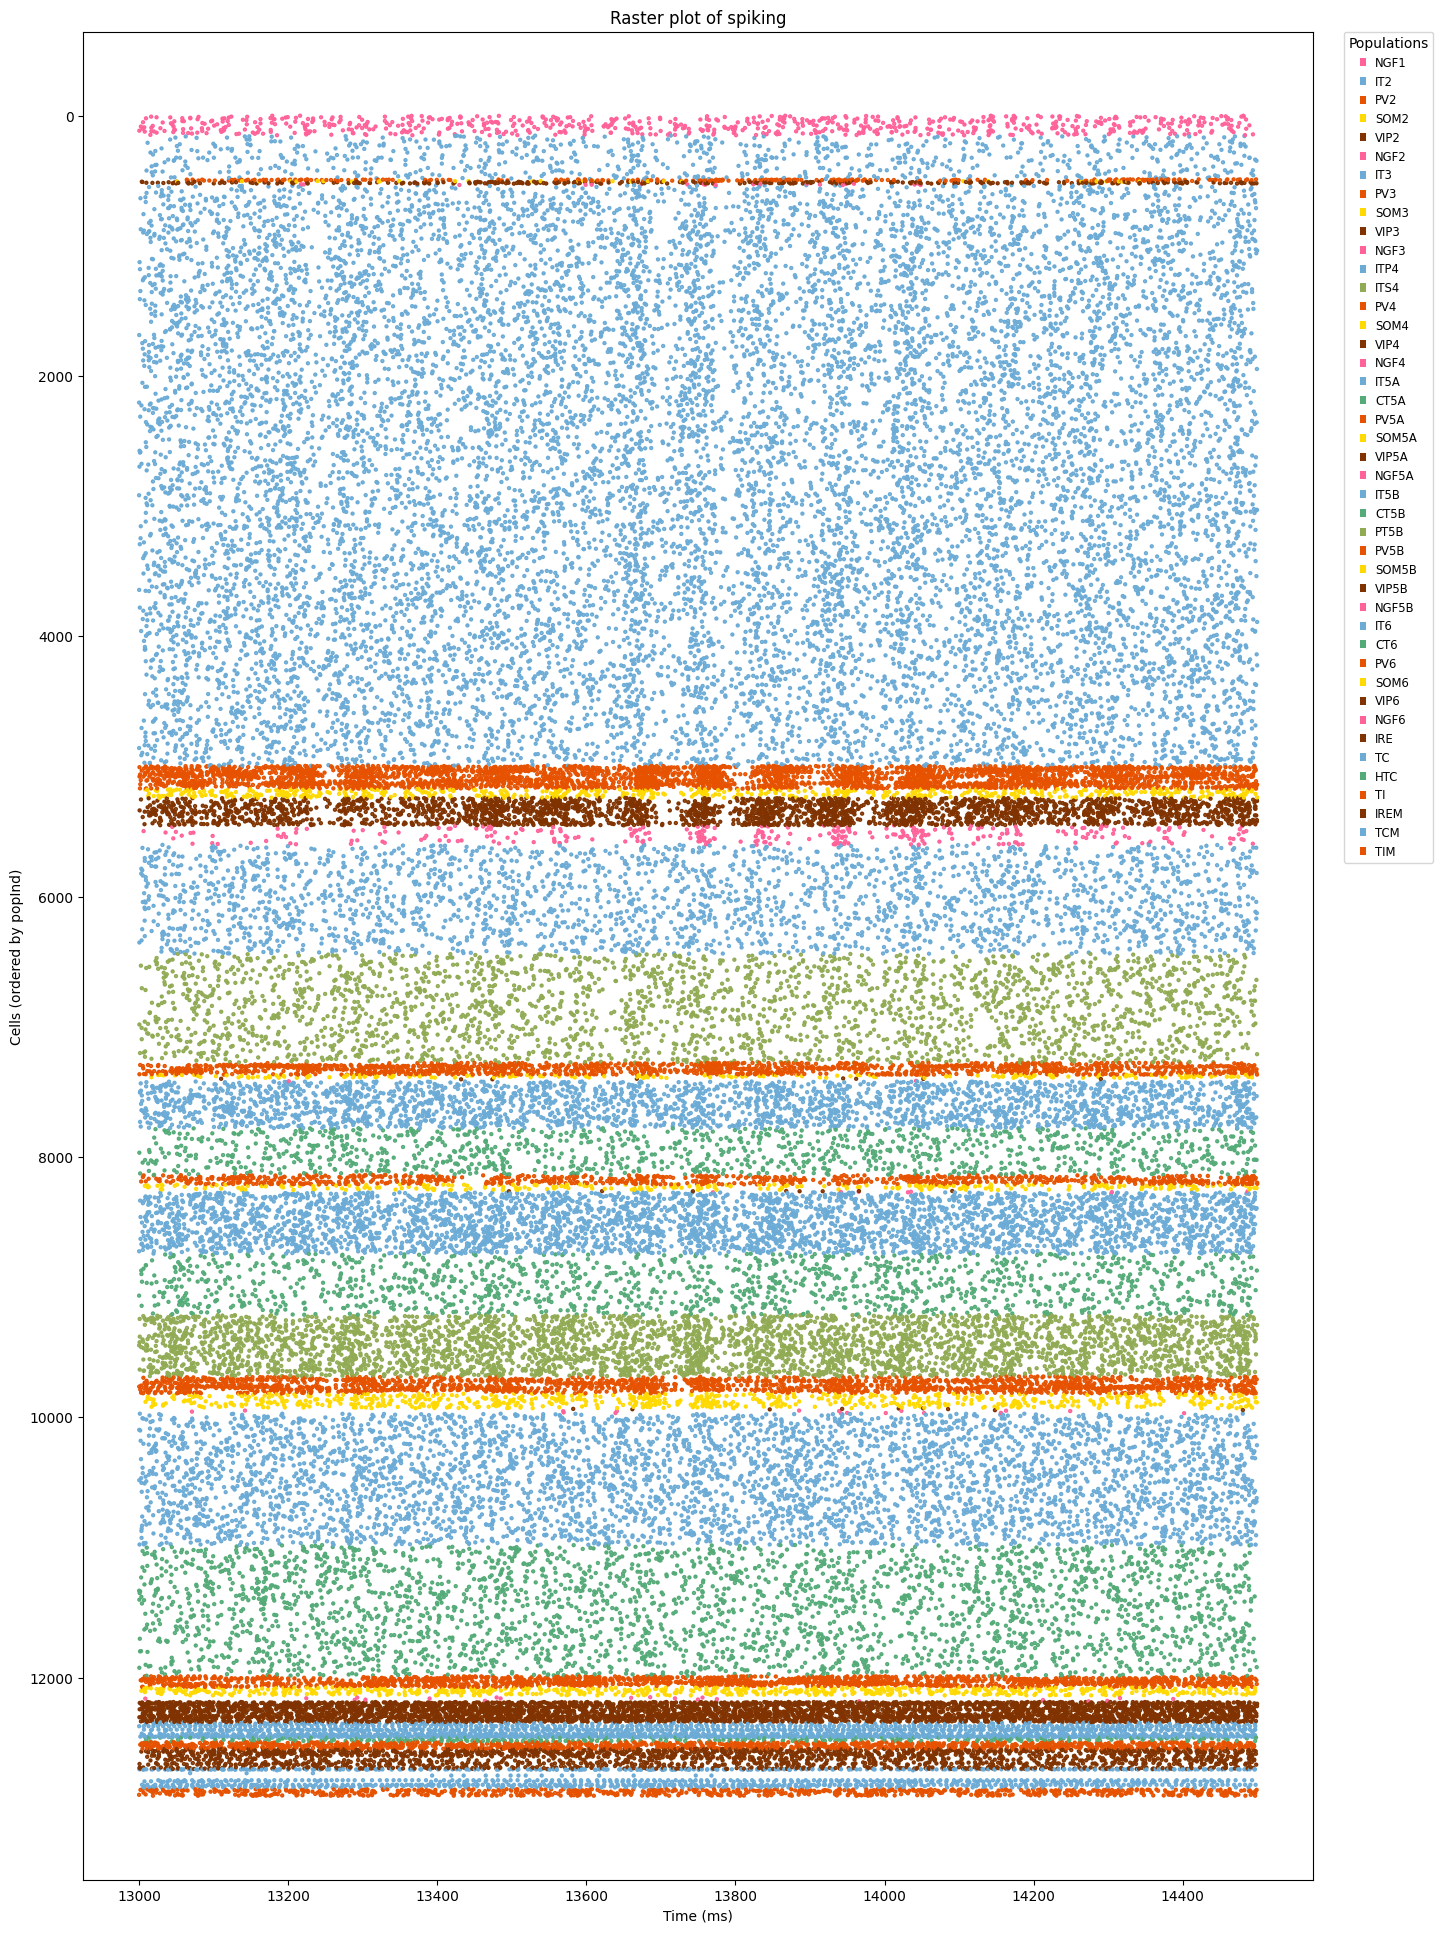

In [47]:
from netpyne import sim

sim.initialize()
sim.net.allCells = sim_res['net']['cells']
sim.net.allPops = sim_res['net']['pops']
sim.allSimData = sim_res['simData']

pops = (
    L1_POPS + L2_POPS + L3_POPS + L4_POPS
    + L5A_POPS + L5B_POPS + L6_POPS
    #+ THAL_RE_POPS + THAL_CORE_POPS + THAL_MATRIX_POPS
    + ['IRE', 'TC', 'HTC', 'TI', 'IREM', 'TCM', 'TIM']
)
pop_colors = make_pop_colors_from_groups(color_groups)

ordered_pops = {
    pop: sim.net.allPops[pop]
    for pop in pops
}

sim.net.allPops = ordered_pops
sim.net.pops = ordered_pops

sim.analysis.plotRaster(
    include=pops,
    showFig=True,
    #timeRange=(6000, 7500),
    timeRange=(13000, 14500),
    orderBy='pop',
    orderInverse=1,
    markerSize=1,
    marker='.',
    popColors=pop_colors,
    #figSize=(10, 12)
    figSize=(20, 24)
    #figSize=(25, 30)
)

In [48]:
pop_colors

{'IT2': [0.42, 0.67, 0.84],
 'IT3': [0.42, 0.67, 0.84],
 'ITP4': [0.42, 0.67, 0.84],
 'IT5A': [0.42, 0.67, 0.84],
 'IT5B': [0.42, 0.67, 0.84],
 'IT6': [0.42, 0.67, 0.84],
 'TC': [0.42, 0.67, 0.84],
 'TCM': [0.42, 0.67, 0.84],
 'PV2': [0.9, 0.32, 0.0],
 'PV3': [0.9, 0.32, 0.0],
 'PV4': [0.9, 0.32, 0.0],
 'PV5A': [0.9, 0.32, 0.0],
 'PV5B': [0.9, 0.32, 0.0],
 'PV6': [0.9, 0.32, 0.0],
 'TI': [0.9, 0.32, 0.0],
 'TIM': [0.9, 0.32, 0.0],
 'SOM2': [1.0, 0.85, 0.0],
 'SOM3': [1.0, 0.85, 0.0],
 'SOM4': [1.0, 0.85, 0.0],
 'SOM5A': [1.0, 0.85, 0.0],
 'SOM5B': [1.0, 0.85, 0.0],
 'SOM6': [1.0, 0.85, 0.0],
 'CT5A': [0.33, 0.67, 0.47],
 'CT5B': [0.33, 0.67, 0.47],
 'CT6': [0.33, 0.67, 0.47],
 'HTC': [0.33, 0.67, 0.47],
 'NGF1': [1.0, 0.38, 0.6],
 'NGF2': [1.0, 0.38, 0.6],
 'NGF3': [1.0, 0.38, 0.6],
 'NGF4': [1.0, 0.38, 0.6],
 'NGF5A': [1.0, 0.38, 0.6],
 'NGF5B': [1.0, 0.38, 0.6],
 'NGF6': [1.0, 0.38, 0.6],
 'ITS4': [0.57, 0.67, 0.33],
 'PT5B': [0.57, 0.67, 0.33],
 'VIP2': [0.5, 0.2, 0.0],
 'VIP3': [0.